To perform a comparative analysis of the elementary sorting algorithms **(Selection Sort, Bubble Sort, and Insertion Sort)** on different datasets,we can follow these steps:


**Datasets**

1 Sorted numbers: A dataset containing numbers from 1 to 10,000.

2 Reverse sorted numbers: A dataset with numbers from 10,000 to 1.

3 Random numbers: A randomly shuffled dataset of size 10,000.


**Sorting Algorithms**
**Selection Sort:** Repeatedly selects the smallest element from the unsorted portion of the array and swaps it with the first element of the unsorted portion.

**Bubble Sort:** Repeatedly steps through the list, compares adjacent elements, and swaps them if they are in the wrong order.

**Insertion Sort:** Builds the sorted list one element at a time by repeatedly inserting the next element in its correct position within the already sorted portion.

I'll implement this in Python and compute the average run time.


In [17]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

## Performance Comparison

The execution time of Selection Sort, Bubble Sort, and Insertion Sort was measured on three datasets:
- Sorted
- Reverse Sorted
- Random

The following graph compares the average execution time of each algorithm.

In [18]:
# Redefining dataset sizes and selection sort function

# Selection Sort implementation
def selection_sort(arr):
    for i in range(len(arr)):
        min_idx = i
        for j in range(i + 1, len(arr)):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr

# Function to run selection sort and measure time
def run_selection_sort(data):
    start_time = time.time()
    selection_sort(data.copy())
    return time.time() - start_time

# Prepare datasets
n = 10000
sorted_data_10k = list(range(1, n + 1))
reverse_sorted_data_10k = list(range(n, 0, -1))
random_data_10k = random.sample(range(1, n + 1), n)

# Run experiments and measure time for selection sort
def perform_selection_sort_experiment():
    results = {}

    # Timing for sorted data
    sorted_time = run_selection_sort(sorted_data_10k)
    results["Sorted"] = sorted_time

    # Timing for reverse sorted data
    reverse_sorted_time = run_selection_sort(reverse_sorted_data_10k)
    results["Reverse Sorted"] = reverse_sorted_time

    # Timing for random data
    random_time = run_selection_sort(random_data_10k)
    results["Random"] = random_time

    return results

# Perform the experiment
selection_sort_results = perform_selection_sort_experiment()
selection_sort_results


{'Sorted': 2.760209560394287,
 'Reverse Sorted': 4.64566707611084,
 'Random': 4.043728590011597}

In [19]:
# Define the Bubble Sort algorithm
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

# Function to measure the time taken by Bubble Sort
def run_bubble_sort(data):
    start_time = time.time()
    bubble_sort(data.copy())
    return time.time() - start_time

# Prepare datasets of size 10000
n = 10000
sorted_data = list(range(1, n + 1))  # Sorted numbers
reverse_sorted_data = list(range(n, 0, -1))  # Reverse sorted numbers
random_data = random.sample(range(1, n + 1), n)  # Random numbers

# Run Bubble Sort on all datasets
bubble_sort_times = {
    "Sorted": run_bubble_sort(sorted_data),
    "Reverse Sorted": run_bubble_sort(reverse_sorted_data),
    "Random": run_bubble_sort(random_data)
}

bubble_sort_times


{'Sorted': 5.363158941268921,
 'Reverse Sorted': 9.885854005813599,
 'Random': 7.243069410324097}

In [20]:
# Insertion Sort implementation
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

    return arr


# Function to measure execution time
def run_sorting_algorithm(sort_function, data):
    start_time = time.time()
    sort_function(data.copy())
    return time.time() - start_time

In [21]:
# Insertion sort
#  Increase the dataset size to 10,000 for this experiment
n = 10000
sorted_data_large = list(range(1, n + 1))
reverse_sorted_data_large = list(range(n, 0, -1))
random_data_large = random.sample(range(1, n + 1), n)

# Function to run the sort and measure time for large datasets
def perform_insertion_sort_large():
    data_types = {
        "Sorted": sorted_data_large,
        "Reverse Sorted": reverse_sorted_data_large,
        "Random": random_data_large,
    }

    results = {}
    for dtype, data in data_types.items():
        times = []
        for _ in range(3):  # Run three times
            exec_time = run_sorting_algorithm(insertion_sort, data)
            times.append(exec_time)
        results[dtype] = np.mean(times)

    return results

# Run the experiment with larger dataset
results_insertion_sort_large = perform_insertion_sort_large()
results_insertion_sort_large


{'Sorted': np.float64(0.002165555953979492),
 'Reverse Sorted': np.float64(9.381660461425781),
 'Random': np.float64(4.590360959370931)}

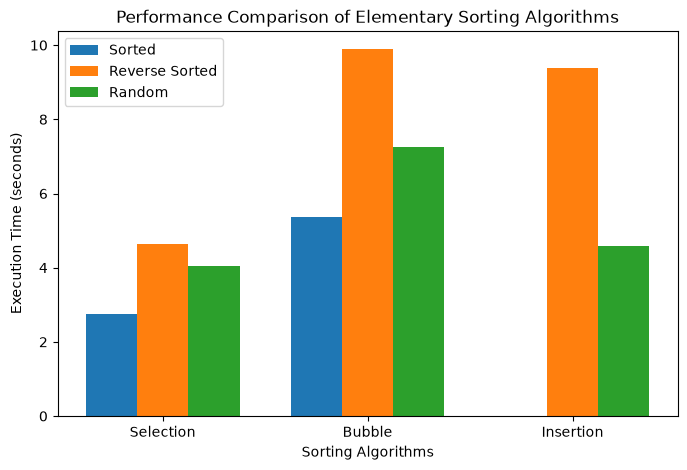

In [22]:
algorithms = ["Selection", "Bubble", "Insertion"]

sorted_times = [
    selection_sort_results["Sorted"],
    bubble_sort_times["Sorted"],
    results_insertion_sort_large["Sorted"]
]

reverse_times = [
    selection_sort_results["Reverse Sorted"],
    bubble_sort_times["Reverse Sorted"],
    results_insertion_sort_large["Reverse Sorted"]
]

random_times = [
    selection_sort_results["Random"],
    bubble_sort_times["Random"],
    results_insertion_sort_large["Random"]
]

x = np.arange(len(algorithms))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, sorted_times, width, label="Sorted")
plt.bar(x, reverse_times, width, label="Reverse Sorted")
plt.bar(x + width, random_times, width, label="Random")

plt.xticks(x, algorithms)
plt.xlabel("Sorting Algorithms")
plt.ylabel("Execution Time (seconds)")
plt.title("Performance Comparison of Elementary Sorting Algorithms")
plt.legend()

plt.savefig("comparison_chart.png", dpi=300, bbox_inches="tight")

plt.show()